# CAD lab : Assignment 1
## Aditya Prabhakar [22CE01001]

### Question 1(a)

- The scalar field is defined as `h(x, y) = 200 - x^2 - 2y^2`, representing a hill surface.
- Ranges for `x` and `y` are created from –20 to 20 with 0.1 spacing.
- `surface()` is used to plot a 3D surface of `h(x, y)`.
- `contour()` is used to generate a 2D contour plot showing level curves.
- These visualizations help understand elevation variation in the hill.


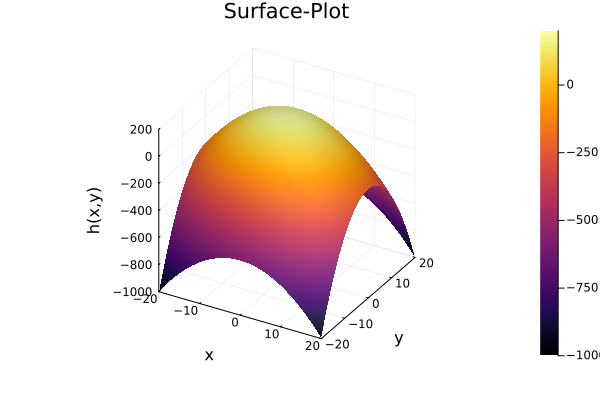

In [1]:
using CalculusWithJulia
using Plots

# Question 1(a)
h(x,y) = 200 - x^2 - 2*y^2

x = -20:0.1:20
y = -20:0.1:20

surface(x, y, h, xlabel = "x", ylabel = "y", zlabel = "h(x,y)", title = "Surface-Plot")

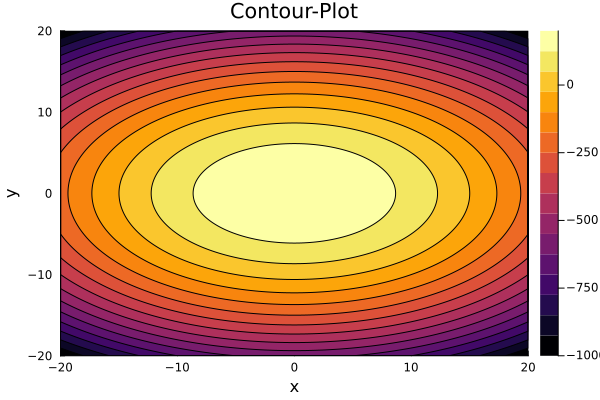

In [2]:
# 2D Contour-Plot

contour(x,y,h, xlabel = "x", ylabel = "y", title = "Contour-Plot",fill=true)

### Question 1(b)

- A smaller grid (−5 to 5) is used for clarity of gradient vectors.
- The gradient at each point is computed using `gradient()` from CalculusWithJulia.
- `U` stores ∂h/∂x and `V` stores ∂h/∂y.
- The gradient vectors are scaled for better visualization (`U .*= 0.04`, `V .*= 0.04`).
- A `quiver` plot is used to show the direction of steepest ascent of the surface.


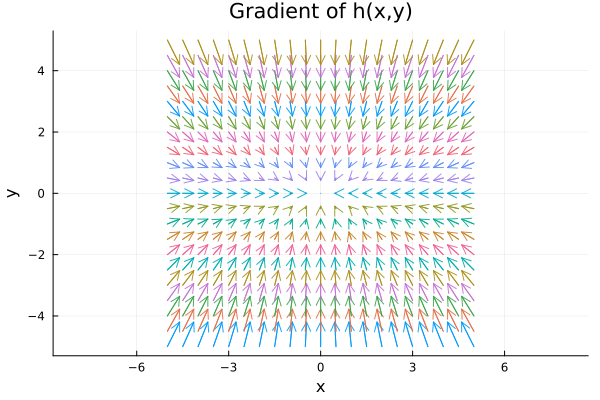

In [4]:
# Question 1(b) 

x2 = -5:0.5:5
y2 = -5:0.5:5

U = [gradient(u -> h(u[1],u[2]),[x,y])[1] for x in x2, y in y2]
V = [gradient(u -> h(u[1],u[2]),[x,y])[2] for x in x2, y in y2]

X = [x for x in x2, y in y2]
Y = [y for x in x2, y in y2]


U .*= 0.04
V .*= 0.04

quiver(X,Y, quiver = (U,V), linealpha=0.9, arrowsize=0.1, aspect_ratio = :equal, title = "Gradient of h(x,y)", xlabel = "x", ylabel = "y")

### Question 1(c)

- The gradient is calculated manually for the function h(x, y).
- ∂h/∂x = −2x and ∂h/∂y = −4y.
- These values are stored in `U_1` and `V_1`.
- The vectors are scaled and plotted using `quiver()`.
- This verifies correctness by matching the automatic gradient plot from part (b).


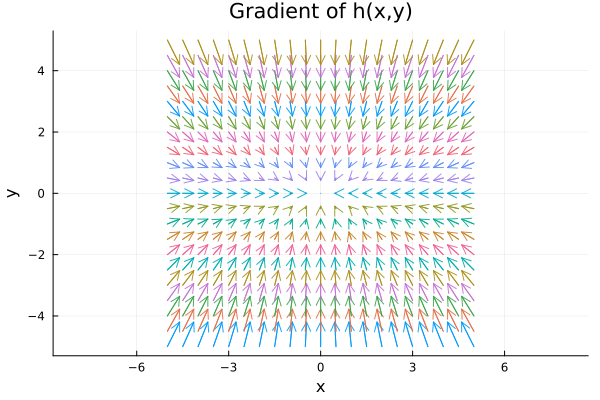

In [5]:
# Question 1(c)

U_1 = [-2*x for x in x2, y in y2]
V_1 = [-4*y for x in x2, y in y2]


U_1 .*= 0.04
V_1 .*= 0.04


quiver(X,Y, quiver = (U_1,V_1), linealpha=0.9, arrowsize=0.1, aspect_ratio = :equal, title = "Gradient of h(x,y)", xlabel = "x", ylabel = "y")

### Question 2(a)

- The cyclone velocity vector field is defined as v(x, y) = [x, −y²].
- Grid values are generated for x and y from −5 to 5.
- The vector components are evaluated at every grid point and stored in `U`, `V`.
- The vectors are scaled and plotted using `quiver()`.
- This plot visualizes wind flow in the cyclone.


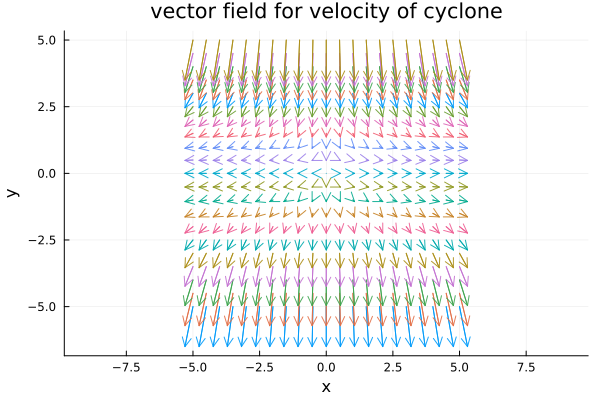

In [36]:
# Question 2(a)

velocity_vector(x,y) = [x,-y^2]

x3 = -5:0.5:5
y3 = -5:0.5:5

U = [velocity_vector(x,y)[1] for x in x3, y in y3]
V = [velocity_vector(x,y)[2] for x in x3, y in y3]

X = [x for x in x3, y in y3]
Y = [y for x in x3, y in y3]


U .*= 0.06
V .*= 0.06

quiver(X,Y, quiver = (U,V), title = "vector field for velocity of cyclone", xlabel = "x", ylabel = "y", linealpha=0.9, arrowsize=0.2, aspect_ratio = :equal)

### Question 2(b)

- The divergence is computed using the automatic tool `divergence()` from CalculusWithJulia.
- Divergence values are plotted using a 3D surface (`surface()`).
- A manual calculation is also done: div = 1 − 2y.
- The manually computed divergence is plotted separately.
- Both results are compared to ensure correctness.


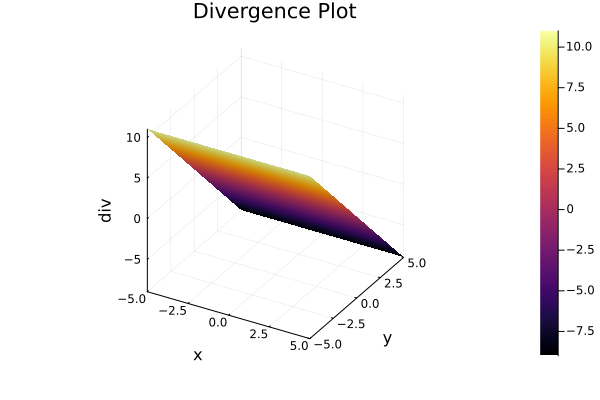

In [7]:
# Question 2(b)

div(x,y) = divergence(u -> velocity_vector(u[1],u[2]),[x,y])

x4 = -5:0.5:5
y4 = -5:0.5:5

surface(x4, y4, div, title = "Divergence Plot", xlabel = "x", ylabel = "y", zlabel = "div")

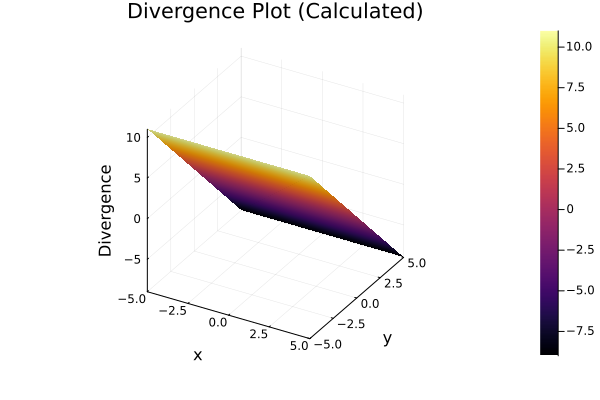

In [7]:
# manual divergence calculation

div_calculated(x,y) = 1 - 2*y
surface(x4, y4, div_calculated, title = "Divergence Plot (Calculated)", xlabel = "x", ylabel = "y", zlabel = "Divergence")

### Question 2(c)

- Curl is calculated using `curl()` from CalculusWithJulia.
- The curl values are visualized using a `heatmap`.
- The velocity vectors are overlaid using `quiver!()` for better interpretation.
- Manual curl computation is also performed and plotted: curl = 0.
- Both plots are compared to verify correctness.


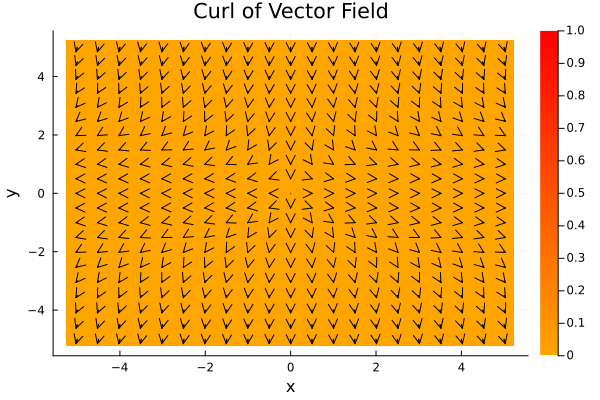

In [8]:
# Question 2(c)

curl_automatic(x,y) = curl(u -> velocity_vector(u[1],u[2]),[x,y])
color_grad = cgrad([:orange, :red],)
heatmap(x3,y3,curl_automatic, c = color_grad)

U .*= 0.1
V .*= 0.1

quiver!(X,Y, quiver = (U,V), colour=:black, title = "Curl of Vector Field", xlabel = "x", ylabel = "y")

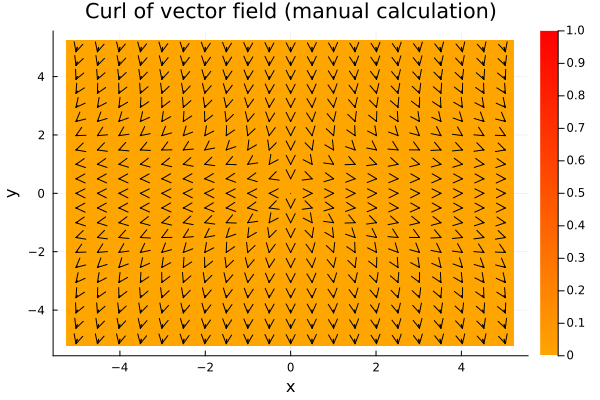

In [11]:
curl_calc = zeros(size(X))

color_grad = cgrad([:orange, :red])
heatmap(x3,y3,curl_calc, colour=:balance, c = color_grad)

quiver!(X,Y, quiver = (U,V), colour=:black, title = "Curl of vector field (manual calculation)", xlabel = "x", ylabel = "y")

### Question 3(a)

- The velocity field for water is defined as f = [e^x * y², x + 2y].
- A grid from −2 to 2 is constructed for plotting.
- Vector components U and V are computed at each point.
- Scaled vectors are plotted using `quiver()`.
- The vector field visualizes water particle motion in the river.


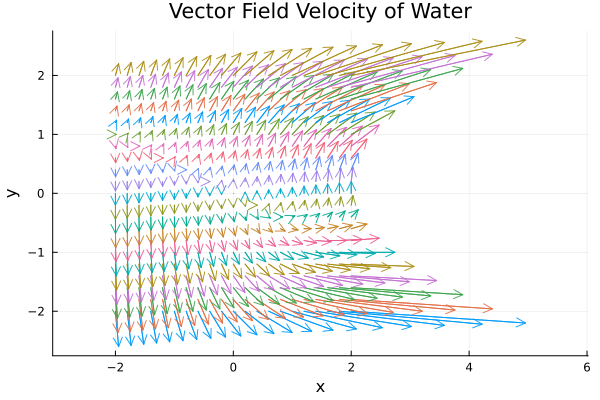

In [12]:
# Question 3(a)

velocity_vector(x,y)=[e^x*y^2,x + 2*y]

x3 = -2:0.2:2
y3 = -2:0.2:2

U = [velocity_vector(x,y)[1] for x in x3, y in y3]
V = [velocity_vector(x,y)[2] for x in x3, y in y3]

X = [x for x in x3, y in y3]
Y = [y for x in x3, y in y3]

U .*= 0.1
V .*= 0.1

quiver(X,Y, quiver = (U,V), title = "Vector Field Velocity of Water", xlabel = "x", ylabel = "y", linealpha=0.9, arrowsize=0.2, aspect_ratio = :equal)

### Question 3(b)

- Automatic divergence is computed using `divergence()`.
- A 3D surface of divergence is plotted over the x–y grid.
- Manual divergence is computed as div = e^x * y² + 2.
- A separate surface is plotted for manual divergence.
- The two surfaces are compared to confirm the automatic result.


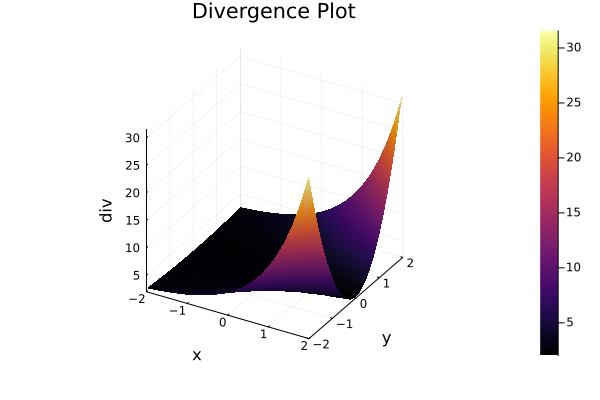

In [7]:
#Question 3(b)

div(x,y) = divergence(u -> velocity_vector(u[1],u[2]),[x,y])

x4 = -2:0.2:2
y4 = -2:0.2:2

surface(x4, y4, div, title = "Divergence Plot", xlabel = "x", ylabel = "y", zlabel = "div")

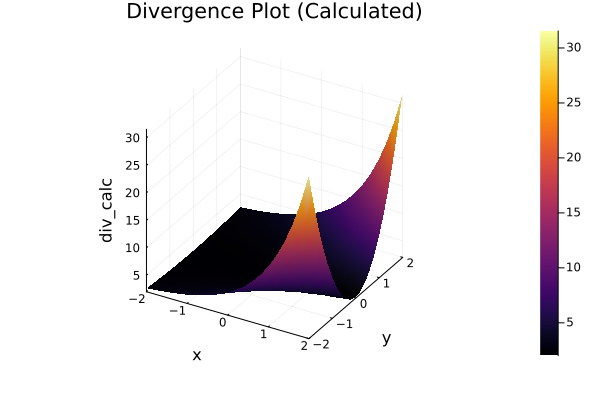

In [8]:
div_calculated(x,y) = (e^x*y^2) + 2
surface(x4, y4, div_calculated, title = "Divergence Plot (Calculated)", xlabel = "x", ylabel = "y", zlabel = "div_calc")

### Question 3(c)

- Curl is computed automatically with `curl()` and plotted as a heatmap.
- Velocity vectors are added using `quiver!()` to show flow direction.
- Manual curl is computed as curl = 1 − (2y * e^x).
- A second heatmap is plotted for the manual curl.
- Both results are compared to validate correctness.


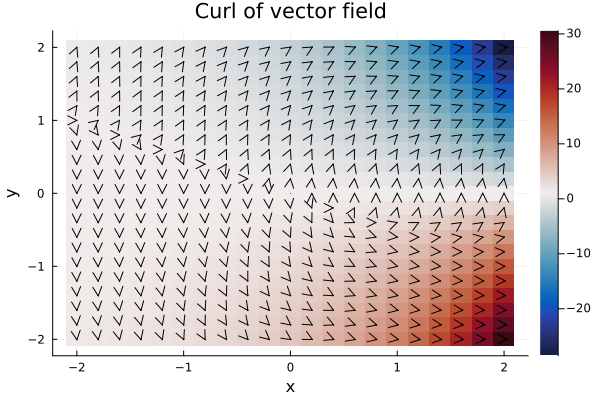

In [26]:
# Question 3(c) (automatic curl calculation)

curl_auto(x,y) = curl(u -> velocity_vector(u[1],u[2]),[x,y])

heatmap(x3,y3,curl_auto, colour=:balance)

U .*= 0.1
V .*= 0.1

quiver!(X,Y, quiver = (U,V), colour=:black, title = "Curl of Vector Field", xlabel = "x", ylabel = "y")

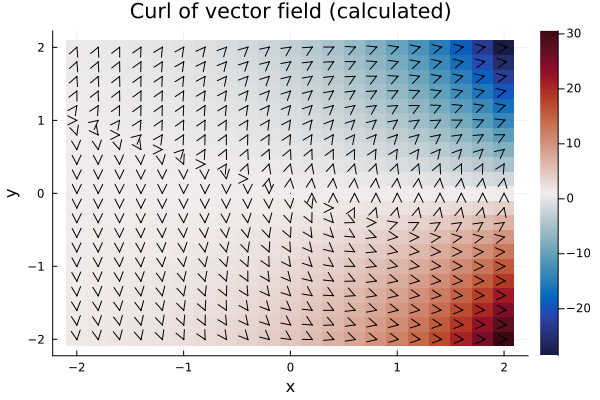

In [28]:
curl_calc_2(x,y) = 1 - (2*y*e^x)
heatmap(x3,y3,curl_calc_2, colour=:balance)

quiver!(X,Y, quiver = (U,V), colour=:black, title = "Curl of vector field (calculated)", xlabel = "x", ylabel = "y")

### Question 4

- Beam length and load intensity (l, q) are defined as variables.
- Support reactions `R_a` and `R_b` are computed using static equilibrium.
- x-values from 0 to 1.25l are generated for plotting.
- Shear Force (V) and Bending Moment (BM) are computed piecewise:
  - One formula applies for x ≤ l.
  - Another applies for x > l.
- SFD and BMD are plotted using `plot()`, with a zero reference line.
- The code is generic and works for any value of l and q.


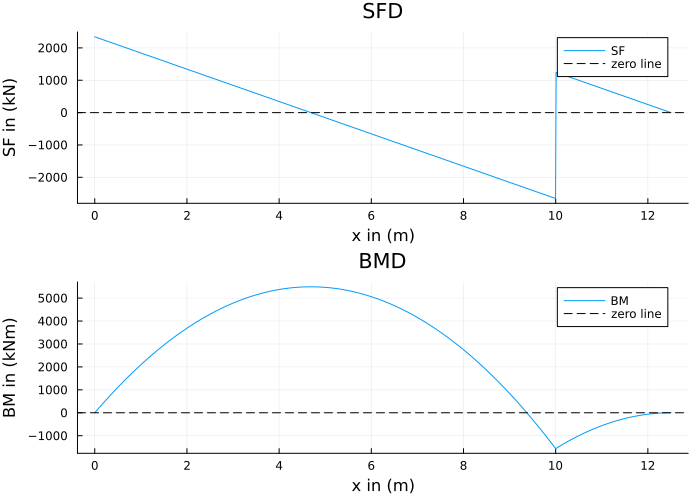

In [34]:
# Question 4

l = 10.0  
q = 500.0  
R_a = 0.46875*q*l
R_b = 0.78125*q*l
x_vals = range(0, 1.25*l, length=1000)
V = zeros(1000)
BM = zeros(1000)
for (i) in 1 : 1000
    x=x_vals[i]
    if 0 <= x <= l 
        V[i] = R_a - q*x
        BM[i] = (R_a*x) - (q*x^2/2)
    else  
        V[i] = R_a + R_b - (q*x)
        BM[i] = (R_a*x) + (R_b*(x - l)) - (q*x^2/2)
    end
end
SFD_plot = plot(x_vals, V,title="SFD", xlabel="x in (m)", ylabel="SF in (kN)", label="SF", legend=:topright)
hline!([0], color=:black, linestyle=:dash, label="zero line") 
BMD_plot = plot(x_vals, BM, title="BMD", xlabel="x in (m)", ylabel="BM in (kNm)", label="BM",)
hline!([0], color=:black, linestyle=:dash, label="zero line")
plot(SFD_plot, BMD_plot, layout=(2, 1), size=(700, 500))

### Question 5

- Defines a more complex beam with three support reactions and a point load.
- x-values are generated from 0 to 2l.
- The shear force and bending moment expressions change across 3 regions:
  1. 0 ≤ x ≤ 0.4l  
  2. 0.4l < x ≤ l  
  3. x > l  
- `if–elseif` logic is used to compute V and BM for each region.
- SFD and BMD are plotted with appropriate labels.
- Code is general and works for any l and q values.


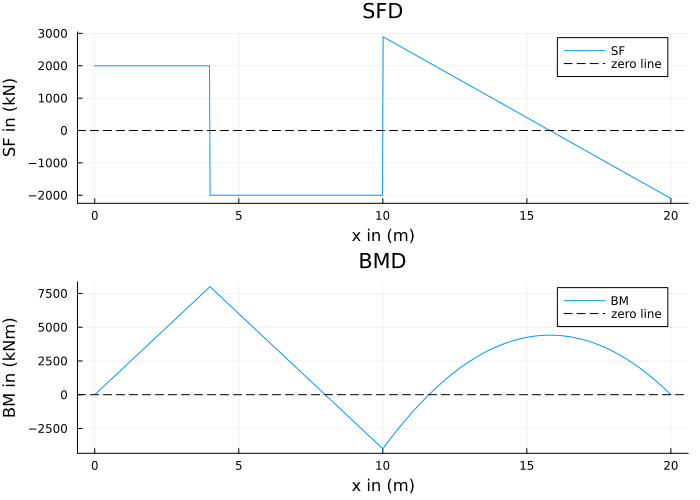

In [40]:
# Question 5

l = 10.0  
q = 500.0 
R_a = 0.4*q*l
R_b = 0.98*q*l
R_c = 0.42*q*l
P = 0.8*q*l
x_vals = range(0, 2*l , length=1000)
V = zeros(1000)
BM = zeros(1000)
for (i) in 1:1000
    x=x_vals[i]
    if  0 <= x <= 0.4*l
        V[i] = R_a
        BM[i] = (R_a*x)
    elseif  x <= l 
        V[i] = R_a - P
        BM[i] = (R_a*x) - (P*(x - 0.4*l))
    else
        V[i] = (R_a - P) + R_b - (q*(x - l))
        BM[i] = (R_a*x) - (P*(x - 0.4*l)) + (R_b*(x - l)) - (q*(x - l)^2/2)
    end
end
SFD_plot = plot(x_vals, V,title="SFD", xlabel="x in (m)", ylabel="SF in (kN)", label="SF", legend=:topright)
hline!([0], color=:black, linestyle=:dash, label="zero line") 
BMD_plot = plot(x_vals, BM, title="BMD", xlabel="x in (m)", ylabel="BM in (kNm)", label="BM",)
hline!([0], color=:black, linestyle=:dash, label="zero line")
plot(SFD_plot, BMD_plot, layout=(2, 1), size=(700, 500))